# Seattle City Wage Data - Data Profiling

Basic exploration and profiling of the City of Seattle employee wage dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('City_of_Seattle_Wage_Data_20260217.csv')
df.columns = df.columns.str.strip()
df['Hourly Rate'] = pd.to_numeric(df['Hourly Rate'], errors='coerce')
print(f'Loaded {len(df):,} rows and {len(df.columns)} columns')

Loaded 13,893 rows and 5 columns


## 1. Shape and Schema

In [2]:
print('--- Shape ---')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print()
print('--- Data Types ---')
print(df.dtypes)
print()
print('--- First 5 Rows ---')
df.head()

--- Shape ---
Rows: 13,893
Columns: 5

--- Data Types ---
Department         str
Last Name          str
First Name         str
Job Title          str
Hourly Rate    float64
dtype: object

--- First 5 Rows ---


,Department,Last Name,First Name,Job Title,Hourly Rate
0,Seattle Police Department,Aagard,Lori,Executive 4,150.43
1,Seattle City Light,Aaltonen,Evan,Powerline Clear Tree Trimmer,61.52
2,Seattle Public Utilities,Aar,Abdimallik,"Civil Engineering Specialist,Senior",70.35
3,Seattle Department of Transportation,Abad,Abigail,Administrative Specialist II-BU,41.31
4,Human Services,Aba-Husain,Adam,"Grants and Contracts Specialist,Senior",50.33


## 2. Missing Values

In [3]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
Department,0,0.0
Last Name,0,0.0
First Name,0,0.0
Job Title,0,0.0
Hourly Rate,0,0.0


## 3. Hourly Rate - Descriptive Statistics

In [4]:
print('--- Hourly Rate Summary ---')
print(df['Hourly Rate'].describe().round(2))
print()
print(f"Median: ${df['Hourly Rate'].median():.2f}")
print(f"Mode:   ${df['Hourly Rate'].mode().iloc[0]:.2f}")
print(f"Range:  ${df['Hourly Rate'].min():.2f} - ${df['Hourly Rate'].max():.2f}")
print(f"IQR:    ${df['Hourly Rate'].quantile(0.25):.2f} - ${df['Hourly Rate'].quantile(0.75):.2f}")

--- Hourly Rate Summary ---
count    13893.00
mean        58.18
std         20.59
min         21.51
25%         42.25
50%         55.19
75%         74.17
max        254.79
Name: Hourly Rate, dtype: float64

Median: $55.19
Mode:   $26.92
Range:  $21.51 - $254.79
IQR:    $42.25 - $74.17


## 4. Hourly Rate Distribution

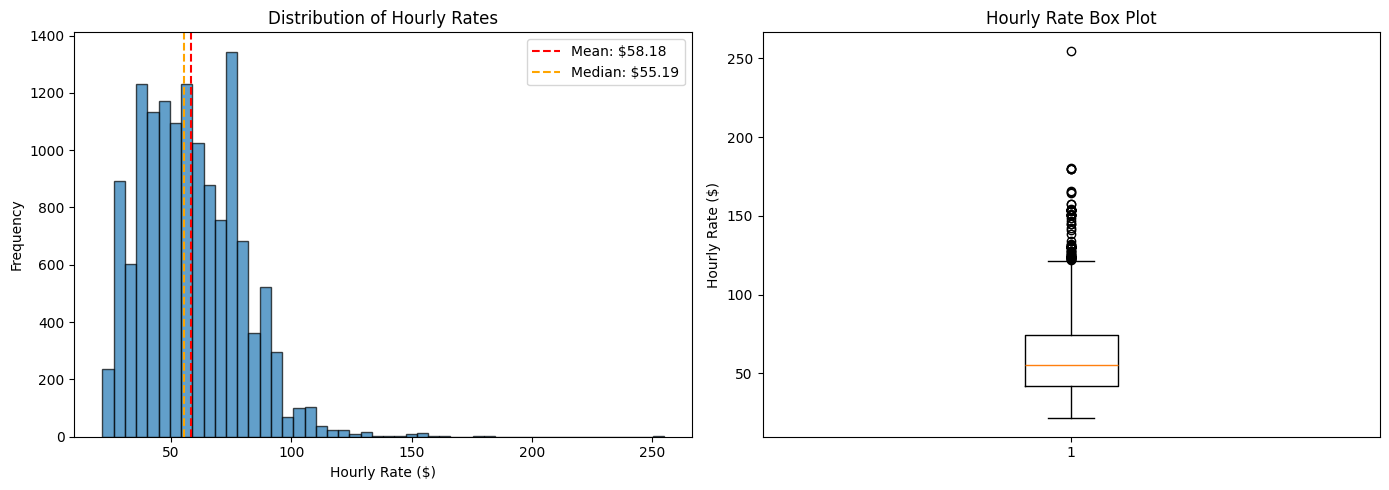

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Hourly Rate'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['Hourly Rate'].mean(), color='red', linestyle='--', label=f"Mean: ${df['Hourly Rate'].mean():.2f}")
axes[0].axvline(df['Hourly Rate'].median(), color='orange', linestyle='--', label=f"Median: ${df['Hourly Rate'].median():.2f}")
axes[0].set_xlabel('Hourly Rate ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Hourly Rates')
axes[0].legend()

axes[1].boxplot(df['Hourly Rate'].dropna(), vert=True)
axes[1].set_ylabel('Hourly Rate ($)')
axes[1].set_title('Hourly Rate Box Plot')

plt.tight_layout()
plt.show()

## 5. Categorical Column Profiles

In [6]:
cat_cols = ['Department', 'Job Title', 'Last Name', 'First Name']
for col in cat_cols:
    print(f'--- {col} ---')
    print(f'  Unique values: {df[col].nunique():,}')
    print(f'  Most common:   {df[col].value_counts().index[0]} ({df[col].value_counts().iloc[0]:,} records)')
    print()

--- Department ---
  Unique values: 41
  Most common:   Parks and Recreation Department (1,815 records)

--- Job Title ---
  Unique values: 1,178
  Most common:   Police Officer-Patrol-BWV (354 records)

--- Last Name ---
  Unique values: 8,377
  Most common:   Nguyen (108 records)

--- First Name ---
  Unique values: 4,479
  Most common:   Michael (229 records)



## 6. Department Breakdown

In [7]:
dept_stats = df.groupby('Department')['Hourly Rate'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)
dept_stats.columns = ['Employee Count', 'Mean Rate', 'Median Rate', 'Min Rate', 'Max Rate']
dept_stats = dept_stats.sort_values('Employee Count', ascending=False)
print(f'Total departments: {len(dept_stats)}')
print()
dept_stats

Total departments: 41



,Employee Count,Mean Rate,Median Rate,Min Rate,Max Rate
Department,,,,,
Parks and Recreation Department,1815,39.39,37.01,21.51,153.70
Seattle City Light,1793,66.83,68.93,22.48,254.79
Seattle Police Department,1630,69.02,76.00,22.48,179.54
Seattle Public Utilities,1545,58.38,55.19,22.48,179.55
Seattle Department of Transportation,1182,59.35,58.61,22.48,153.70
Seattle Fire Department,1078,57.56,55.06,32.75,179.55
Seattle Public Library,645,45.17,41.29,26.93,115.19
Seattle Center,615,41.54,41.69,22.48,141.17
Finance and Administrative Service,579,58.80,55.56,22.48,145.04


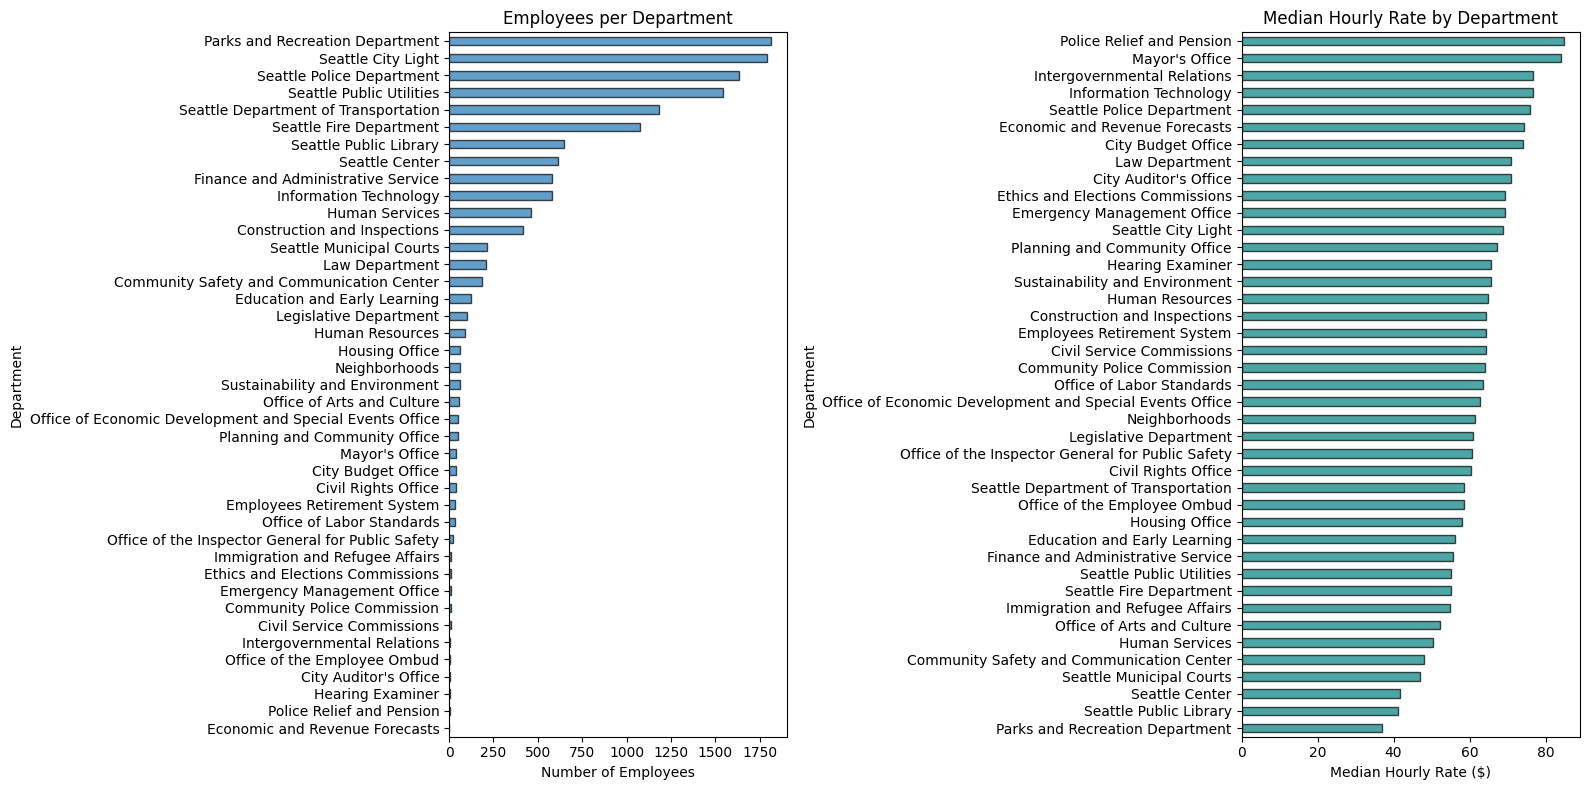

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

dept_counts = dept_stats['Employee Count'].sort_values(ascending=True)
dept_counts.plot(kind='barh', ax=axes[0], edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Employees')
axes[0].set_title('Employees per Department')

dept_median = dept_stats['Median Rate'].sort_values(ascending=True)
dept_median.plot(kind='barh', ax=axes[1], color='teal', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Median Hourly Rate ($)')
axes[1].set_title('Median Hourly Rate by Department')

plt.tight_layout()
plt.show()

## 7. Top Job Titles

In [9]:
title_stats = df.groupby('Job Title')['Hourly Rate'].agg(['count', 'mean', 'median']).round(2)
title_stats.columns = ['Count', 'Mean Rate', 'Median Rate']
print('Top 20 Job Titles by Headcount')
title_stats.sort_values('Count', ascending=False).head(20)

Top 20 Job Titles by Headcount


,Count,Mean Rate,Median Rate
Job Title,,,
Police Officer-Patrol-BWV,354,76.43,76.46
Information Technology Professional B BU,341,76.32,76.31
Lifeguard,324,26.95,26.92
Maintenance Laborer,313,37.95,37.95
Firefighter-90.46 Hrs,293,47.87,48.88
Recreation Attendant,256,28.12,26.92
Firefighter-Ap Driver C-90.46,166,55.04,55.06
Counselor,152,48.81,50.42
Laborer,150,32.65,31.97


## 8. Highest and Lowest Paid Roles

In [10]:
print('--- 10 Highest Hourly Rates ---')
display(df.nlargest(10, 'Hourly Rate')[['Department', 'Job Title', 'First Name', 'Last Name', 'Hourly Rate']])

print()
print('--- 10 Lowest Hourly Rates ---')
display(df.nsmallest(10, 'Hourly Rate')[['Department', 'Job Title', 'First Name', 'Last Name', 'Hourly Rate']])

--- 10 Highest Hourly Rates ---


,Department,Job Title,First Name,Last Name,Hourly Rate
7350,Seattle City Light,City Light General Manager & CEO,Dawn,Lindell,254.79
5220,Seattle City Light,"Electric Utility Executive 3,Officer",Michael,Haynes,180.16
7129,Seattle Public Utilities,SPU General Manager & CEO,Andrew,Lee,179.55
11109,Seattle Fire Department,Fire Chief,Harold,Scoggins,179.55
788,Seattle Police Department,Seattle Police Chief,Shon,Barnes,179.54
11922,Seattle City Light,"Electric Utility Executive 3,Officer",Andrew,Strong,165.81
4661,Seattle City Light,"Electric Utility Executive 3,Officer",Kirsty,Grainger,165.43
7402,Information Technology,Chief Technology Officer,Robert,Lloyd,164.61
6114,Seattle City Light,"Electric Utility Executive 3,Director",DaVonna,Johnson,157.52
11517,Seattle City Light,"Electric Utility Executive 3,Director",Ronald,Smith,157.52



--- 10 Lowest Hourly Rates ---


,Department,Job Title,First Name,Last Name,Hourly Rate
24,Parks and Recreation Department,High School Intern,Mohamed,Abdirahman,21.51
30,Parks and Recreation Department,High School Intern,Majid,Abdulkadir,21.51
203,Parks and Recreation Department,High School Intern,Serafina,Alberto,21.51
285,Parks and Recreation Department,High School Intern,Amirah,Allen,21.51
365,Parks and Recreation Department,Work Training Enrollee,Joey,Ancheta,21.51
462,Parks and Recreation Department,High School Intern,Selamawet,Antneh,21.51
799,Parks and Recreation Department,Work Training Enrollee,Imane,Barnett Osgood,21.51
889,Parks and Recreation Department,Work Training Enrollee,Khiry,Battle,21.51
912,Parks and Recreation Department,Work Training Enrollee,Denny,Bazan,21.51
959,Parks and Recreation Department,High School Intern,Gamada,Bedeso,21.51


## 9. Duplicate Check

In [11]:
exact_dupes = df.duplicated().sum()
name_dupes = df.duplicated(subset=['First Name', 'Last Name']).sum()
print(f'Exact duplicate rows:        {exact_dupes:,}')
print(f'Duplicate name combinations:  {name_dupes:,}')
if name_dupes > 0:
    print()
    print('Sample duplicate names (people in multiple roles or departments):')
    dup_names = df[df.duplicated(subset=['First Name', 'Last Name'], keep=False)]
    display(dup_names.sort_values(['Last Name', 'First Name']).head(10))

Exact duplicate rows:        0
Duplicate name combinations:  121

Sample duplicate names (people in multiple roles or departments):


,Department,Last Name,First Name,Job Title,Hourly Rate
85,Seattle Fire Department,Adams,Samuel,Firefighter-90.46 Hrs,51.46
86,Seattle Fire Department,Adams,Samuel,Firefighter-90.46 Hrs,46.31
265,Seattle Police Department,Allen,David,Police Sergeant-Patrol-BWV,87.98
275,Seattle Department of Transportation,Allen,David,"Transportation Planner,Associate",62.90
264,Seattle Fire Department,Allen,Michael,Office/Maintenance Aide,32.75
286,Office of Arts and Culture,Allen,Michael,"Management Systems Analyst,Senior",58.51
394,Seattle City Light,Anderson,Aaron,Electrical Power Systems Engineer,86.01
400,Seattle Public Utilities,Anderson,Aaron,Capital Projects Coordinator Supervisor,77.64
408,Seattle Fire Department,Anderson,Brian,Fire Captain-90.46 Hrs,68.05
410,Information Technology,Anderson,Brian,Information Technology Professional B BU,77.69
